<a href="https://colab.research.google.com/github/niharikareddem30-oss/FUTURE_ML_01/blob/main/Sales_Forecasting_Task1_Niharika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.shape


(9994, 21)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort data by date
df = df.sort_values('Order Date')

# Group sales by month
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='M')
)['Sales'].sum().reset_index()

# Show first few rows
monthly_sales.head()

/tmp/ipykernel_2042/4213990901.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='Order Date', freq='M')


,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


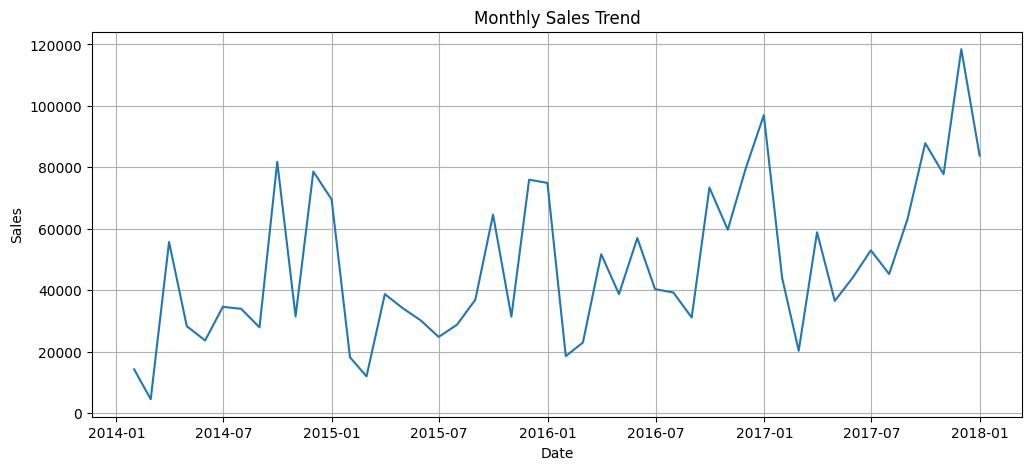

In [ ]:
import matplotlib.pyplot as plt

# Plot monthly sales trend
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Order Date'],
         monthly_sales['Sales'])

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)

plt.show()

In [ ]:
# Create time feature
monthly_sales['Month_Number'] = range(len(monthly_sales))

# Define X and y
X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

# Split data into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Import and train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 20460.74244429802
RMSE: 24075.854608213576


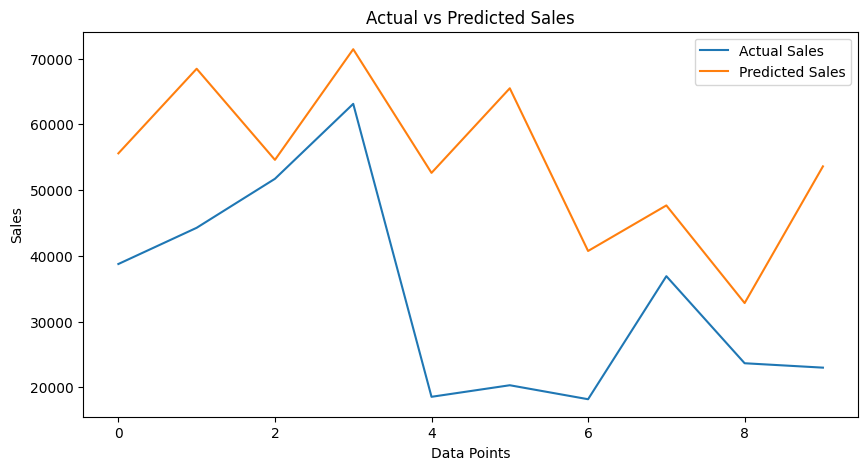

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred, label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Data Points')
plt.ylabel('Sales')
plt.legend()

plt.show()

In [ ]:
# Predict next 12 months sales

future_months = pd.DataFrame({
    'Month_Number': range(
        len(monthly_sales),
        len(monthly_sales) + 12
    )
})

future_predictions = model.predict(future_months)

# Create forecast dataframe
future_dates = pd.date_range(
    start=monthly_sales['Order Date'].max(),
    periods=13,
    freq='M'
)[1:]

forecast_df = pd.DataFrame({
    'Future Date': future_dates,
    'Predicted Sales': future_predictions
})

forecast_df

/tmp/ipykernel_2042/2717793638.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


,Future Date,Predicted Sales
0,2018-01-31,76385.373308
1,2018-02-28,77375.755650
2,2018-03-31,78366.137992
3,2018-04-30,79356.520334
4,2018-05-31,80346.902676
5,2018-06-30,81337.285018
6,2018-07-31,82327.667360
7,2018-08-31,83318.049702
8,2018-09-30,84308.432043
9,2018-10-31,85298.814385


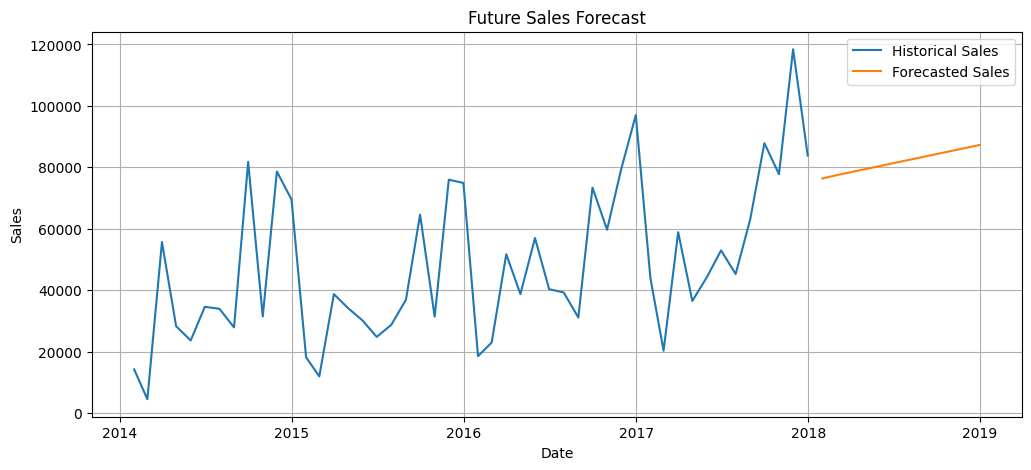

In [ ]:
plt.figure(figsize=(12,5))

# Historical sales
plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    label='Historical Sales'
)

# Future forecast
plt.plot(
    forecast_df['Future Date'],
    forecast_df['Predicted Sales'],
    label='Forecasted Sales'
)

plt.title('Future Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.show()

# Conclusion

In this project, a sales forecasting system was developed using historical Superstore sales data. The dataset was cleaned and analyzed to understand sales trends over time. Monthly sales patterns were prepared and used to train a Linear Regression model for forecasting future sales.

The model successfully predicted future sales trends and provided insights into business growth patterns. Forecast visualizations helped make predictions easier to understand for non-technical stakeholders.

This forecasting system can support businesses in inventory planning, financial management, staffing decisions, and strategic planning by helping anticipate future demand.
